In [ ]:
#pip install matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats as stats
matplotlib.style.use('ggplot')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Github/mtcars.csv')
df

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [ ]:
df.shape

(32, 12)

In [ ]:
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
mpg,0
cyl,0
disp,0
hp,0
drat,0
wt,0
qsec,0
vs,0
am,0


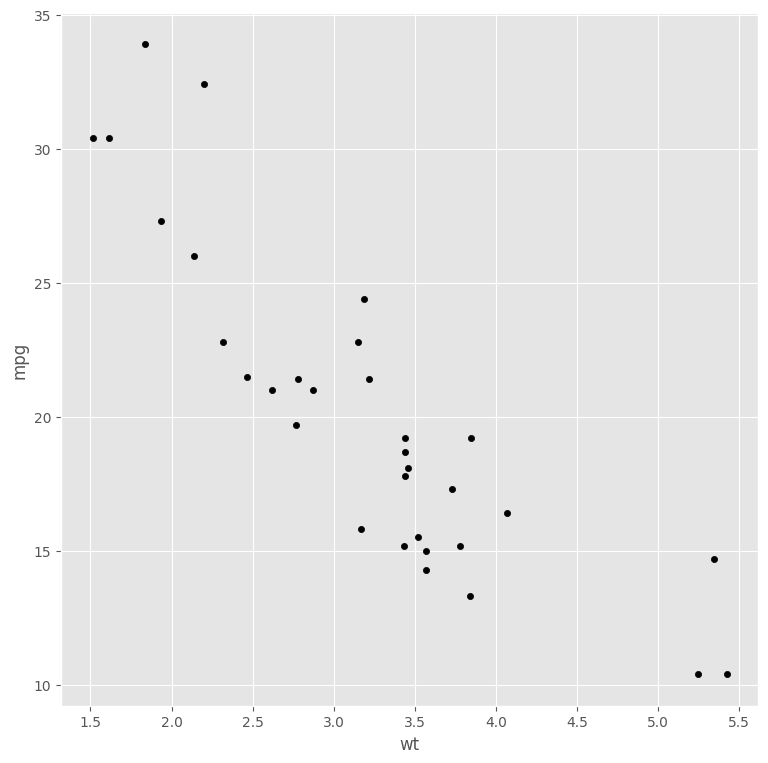

In [ ]:
df.plot(kind='scatter',
        x='wt',
        y='mpg',
        figsize=(9,9),
        color='black');

In [ ]:
# The scatterplot shows a roughly linear relationship between weight and mpg, suggesting a linear regresion model might work well.
# Python scikit -learn library contains a wide range of function for predictive modeling. Lets load its linear regression training function and fit a line to mtcars data
from sklearn import linear_model

#Intialize model
regression_model = linear_model.LinearRegression()

#Train the model using the mtcarss data
regression_model.fit (X = pd.DataFrame(df['wt']),y = df['mpg'])

# Check trained model y-intercept
print(regression_model.intercept_)

# Check trained model coefficients
print(regression_model.coef_)


37.28512616734204
[-5.34447157]


In [ ]:
# The output above shows the model intercept and coefficients used to create the best fit line. In this case the y-intercept term is set to 37.2851 and the coefficient for the weight variable is -5.3445.
# In other words, the model fit the line: mpg = 37.2 - 5.3 *wt
# We can get a sense of how much variance in the response varibale is explained by the model using the model.score() fucntion:

regression_model.score(X=pd.DataFrame(df['wt']), y =df['mpg'])

# The output of the score function for linear regression is R-Squared,  a value that ranges from 0 to 1 which descibes the proportion of variance in the response variable that is explained by the model. In this case,
# car weight explains roughly 75% of the variance in mpg.

#The R-squared measure is based on the residuals: differences between what the model predicts for each data point and the actual value of each data point. We can extract the model's residual by making a prediction with
# the model on the data and then subtracting the actual value from each prediction:

train_prediction = regression_model.predict(X = pd.DataFrame(df['wt']))

# Actual - prediction = residuals
residuals = df['mpg'] - train_prediction

residuals.describe()


,mpg
count,3.200000e+01
mean,-8.215650e-15
std,2.996352e+00
min,-4.543151e+00
25%,-2.364709e+00
50%,-1.251956e-01
75%,1.409561e+00
max,6.872711e+00


In [ ]:
SSResiduals = (residuals**2).sum()
SSTotal = ((df['mpg'] - df['mpg'].mean())**2).sum()

# R-Squared
1 - (SSResiduals/SSTotal)

# Now that we have our linear model, lets plot the line it fi

np.float64(0.7528327936582646)